## **LOAD DATA TOKOPEDIA**

In [1]:
import pandas as pd

In [2]:
tokopedia = pd.read_csv('/content/data_tokopedia_kotor.csv')
tokopedia

,link_produk,potongan_harga,type_hp,harga,harga_awal,promo,rating,terjual,toko,lokasi_toko
0,https://www.tokopedia.com/midnight3467/infnix-...,45%,"Infnix NOTE 40 Pro 5G - HP Flagship Gaming, Ka...",Rp1.309.846,Rp2.381.539,Bisa COD,3.6,70+ terjual,Midnight3467,Kab. Tangerang
1,https://www.tokopedia.com/boss-cellular/promo-...,78%,[ Promo Akhir Tahun ] Iphone 17 Pro Max 1 TERA...,Rp2.888.000,Rp13.000.000,Bisa COD,5.0,4 terjual,BOSS Cellular_NEW,Jakarta Barat
2,https://www.tokopedia.com/asia-jaya-cellular/i...,72%,INFINIX HOT 50 NFC 8/128 GB GARANSI INDONESIA,Rp1.019.538,Rp3.641.204,Bisa COD,5.0,2 terjual,Asia Jaya Cellular,Kab. Bekasi
3,https://www.tokopedia.com/mczstore/exclusive-p...,40%,[EXCLUSIVE PUTRA SIREGAR] itel A100C 3+64GB | ...,Rp1.138.990,Rp1.899.000,Hemat s.d 1% Pakai Bonus,4.9,60+ terjual,MC Z STORE,Jakarta Barat
4,https://www.tokopedia.com/advanstore/free-case...,53%,(FREE CASE) ADVAN X1 Mediatek Helio G100 8GB+8...,Rp1.899.000,Rp3.999.000,Hemat s.d 1% Pakai Bonus,4.9,3rb+ terjual,ADVAN INDONESIA,Kab. Tangerang
...,...,...,...,...,...,...,...,...,...,...
916,https://www.tokopedia.com/bahristore59/tempere...,16%,Tempered Glass Kaca Glossy Viv premium Gelap ...,Rp73.000,Rp20.000,Hemat s.d 1% Pakai Bonus,4.6,3rb+ terjual,hop market,Jakarta Barat
917,https://www.tokopedia.com/fashionselular/oneso...,45%,OneSOS Folding Desktop Phone Stand Holder Ka...,Rp2.600,Rp40.000,Hemat s.d 1% Pakai Bonus,4.9,500+ terjual,Fashion Selular_NEW,Jakarta Barat
918,https://www.tokopedia.com/fusion21/pen-stylus-...,49%,Pen Stylus Tablet Smartphone Pulpen Stilus Lay...,Rp1.500,Rp2.128.000,Bisa COD,4.9,6rb+ terjual,Jilljazz21,Jakarta Barat
919,https://www.tokopedia.com/emelda-susanti/origi...,NaN,Original Y12S phone 16G RAM+512GB ROM Cellpho...,Rp2.160.000,NaN,Bisa COD,NaN,NaN,EMELDA SUSANTI,Jakarta Utara


## **PREPROCESSING**

In [3]:
# Struktur data
tokopedia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921 entries, 0 to 920
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   link_produk     921 non-null    object 
 1   potongan_harga  791 non-null    object 
 2   type_hp         921 non-null    object 
 3   harga           843 non-null    object 
 4   harga_awal      857 non-null    object 
 5   promo           919 non-null    object 
 6   rating          907 non-null    float64
 7   terjual         919 non-null    object 
 8   toko            921 non-null    object 
 9   lokasi_toko     921 non-null    object 
dtypes: float64(1), object(9)
memory usage: 72.1+ KB


In [4]:
# Pengecekan missing value
tokopedia.isnull().sum()

,0
link_produk,0
potongan_harga,130
type_hp,0
harga,78
harga_awal,64
promo,2
rating,14
terjual,2
toko,0
lokasi_toko,0


In [5]:
# Pengecekan data duplikat
tokopedia.duplicated().sum()

np.int64(53)

#### Seleksi Kolom (Drop yang Tidak Digunakan)

In [6]:
# Kolom yang digunakan
kolom_tokopedia = ['type_hp', 'harga', 'terjual', 'lokasi_toko']
tokopedia = tokopedia[kolom_tokopedia].copy()

print("Kolom setelah diseleksi:", tokopedia.columns.tolist())
print("Shape:", tokopedia.shape)

Kolom setelah diseleksi: ['type_hp', 'harga', 'terjual', 'lokasi_toko']
Shape: (921, 4)


In [7]:
# Rename kolom
tokopedia = tokopedia.rename(columns = {
    'type_hp': 'Produk',
    'harga': 'Harga_Produk',
    'terjual': 'Produk_Terjual',
    'lokasi_toko': 'Lokasi_Toko'})

print("Kolom setelah rename:", tokopedia.columns.tolist())

Kolom setelah rename: ['Produk', 'Harga_Produk', 'Produk_Terjual', 'Lokasi_Toko']


#### Tambahkan Kolom Identitas Platform

In [8]:
tokopedia['E-Commerce'] = 'tokopedia'
print(tokopedia['E-Commerce'].value_counts())

E-Commerce
tokopedia    921
Name: count, dtype: int64


In [9]:
tokopedia.head()

,Produk,Harga_Produk,Produk_Terjual,Lokasi_Toko,E-Commerce
0,"Infnix NOTE 40 Pro 5G - HP Flagship Gaming, Ka...",Rp1.309.846,70+ terjual,Kab. Tangerang,tokopedia
1,[ Promo Akhir Tahun ] Iphone 17 Pro Max 1 TERA...,Rp2.888.000,4 terjual,Jakarta Barat,tokopedia
2,INFINIX HOT 50 NFC 8/128 GB GARANSI INDONESIA,Rp1.019.538,2 terjual,Kab. Bekasi,tokopedia
3,[EXCLUSIVE PUTRA SIREGAR] itel A100C 3+64GB | ...,Rp1.138.990,60+ terjual,Jakarta Barat,tokopedia
4,(FREE CASE) ADVAN X1 Mediatek Helio G100 8GB+8...,Rp1.899.000,3rb+ terjual,Kab. Tangerang,tokopedia


#### Filter Produk HP (Drop Selain Produk HP)

In [10]:
# Membuat kata kunci penanda produk non-hp
non_hp_keywords = ['headset', 'earphone', 'earbuds', 'tws', 'charger', 'casing',
                   'softcase', 'hardcase', 'tempered', 'glass', 'kabel', 'cable',
                   'powerbank', 'power bank', 'lcd', 'spare', 'baterai', 'battery',
                   'tripod', 'holder', 'stand', 'stylus', 'adapter', 'converter',
                   'memory', 'micro sd', 'microsd', 'tablet', 'smartwatch', 'watch',
                   'mesin', 'minus', 'no pola', 'rusak', 'icloud', 'tas hp',
                   'tas handphone','case for iphone', 'case for hp', 'speaker',
                   'gimbal', 'stabilizer', 'rak handphone', 'rak hp', 'gantungan',
                   'plat gantung', 'sarung hp', 'kantong hp', 'mystery box', 'misteri box',
                   'dus ', 'kotak kosong', 'cleaning kit', 'microphone', 'wireless mic',
                   'laptop', 'notebook', 'tablet', 'pad ']

def is_hp(judul):
    judul_lower = str(judul).lower()
    for kw in non_hp_keywords:
        if kw in judul_lower:
            return False
    return True

sebelum = tokopedia.shape[0]
tokopedia = tokopedia[tokopedia['Produk'].apply(is_hp)].reset_index(drop = True)
sesudah = tokopedia.shape[0]

print(f"Baris sebelum filter: {sebelum}")
print(f"Baris setelah filter: {sesudah}")
print(f"Produk non-HP yang dibuang: {sebelum - sesudah}")

Baris sebelum filter: 921
Baris setelah filter: 639
Produk non-HP yang dibuang: 282


#### Cleaning Kolom Harga Produk

In [11]:
tokopedia['Harga_Produk'] = (
    tokopedia['Harga_Produk']
    .astype(str)
    .str.replace('Rp', '', regex=False)   # hapus prefix Rp
    .str.replace('.', '', regex=False)    # hapus titik pemisah ribuan
    .str.replace(',', '', regex=False)    # hapus koma jika ada
    .str.strip()
)

tokopedia['Harga_Produk'] = pd.to_numeric(tokopedia['Harga_Produk'], errors = 'coerce')

In [12]:
HARGA_MIN = 100_000
HARGA_MAX = 25_000_000

tokopedia = tokopedia[
    (tokopedia['Harga_Produk'] >= HARGA_MIN) &
    (tokopedia['Harga_Produk'] <= HARGA_MAX)
].reset_index(drop = True)

In [13]:
# Tipe data
print("Tipe data harga:", tokopedia['Harga_Produk'].dtype)

Tipe data harga: float64


In [14]:
# Pengecekan missing value kolom harga produk
tokopedia['Harga_Produk'].isnull().sum()

np.int64(0)

In [15]:
# Statistika deskriptif
tokopedia['Harga_Produk'].describe()

,Harga_Produk
count,5.770000e+02
mean,2.777681e+06
std,3.309427e+06
min,1.150000e+05
25%,1.000000e+06
50%,1.560000e+06
75%,3.099000e+06
max,2.403900e+07


#### Cleaning Kolom Produk Terjual

In [16]:
import numpy as np
import re

In [17]:
def parse_terjual_tokopedia(val):
    val = str(val).lower().strip()

    # Hapus kata terjual dan sold
    val = val.replace('terjual', '').replace('sold', '').strip()

    # Hapus tanda + (misal "70+" jadi "70")
    val = val.replace('+', '').strip()

    # Handle format rb
    match_rb = re.search(r'([\d.,]+)\s*rb', val)
    if match_rb:
        angka = match_rb.group(1).replace(',', '').replace('.', '')
        return float(angka) * 1000

    # Handle format k
    match_k = re.search(r'([\d.,]+)\s*k', val)
    if match_k:
        angka = match_k.group(1).replace(',', '').replace('.', '')
        return float(angka) * 1000

    # Handle angka biasa
    val_clean = re.sub(r'[^\d]', '', val)
    if val_clean:
        return float(val_clean)

    return np.nan

tokopedia['Produk_Terjual'] = tokopedia['Produk_Terjual'].apply(parse_terjual_tokopedia)
tokopedia['Produk_Terjual'] = pd.to_numeric(tokopedia['Produk_Terjual'], errors = 'coerce')

In [18]:
# Tipe data
print("Tipe data terjual:", tokopedia['Produk_Terjual'].dtype)

Tipe data terjual: float64


In [19]:
# Pengecekan missing value
tokopedia['Produk_Terjual'].isnull().sum()

np.int64(1)

In [20]:
# Statistika deskriptif
tokopedia['Produk_Terjual'].describe().round(3)

,Produk_Terjual
count,576.000
mean,308.910
std,1080.803
min,1.000
25%,5.000
50%,30.000
75%,100.000
max,10000.000


#### Cleaning Kolom Kota

In [21]:
tokopedia['Lokasi_Toko'].unique()

array(['Kab. Tangerang', 'Jakarta Barat', 'Kab. Bekasi', 'Tangerang',
       'Jakarta Utara', 'Kab. Pasuruan', 'Kab. Bandung', 'Surabaya',
       'Pekanbaru', 'Jakarta Pusat', 'Jakarta Timur', 'Medan',
       'Kab. Kudus', 'Padang', 'Kab. Malang', 'Kab. Cirebon',
       'Kab. Tegal', 'Semarang', 'Kab. Hulu Sungai Selatan',
       'Tasikmalaya', 'Kab. Bogor', 'Bandung', 'Kab. Bondowoso',
       'Kab. Deli Serdang', 'Kab. Lampung Utara', 'Malang', 'Pontianak',
       'Palembang', 'Jakarta Selatan', 'Kab. Lumajang',
       'Kab. Bandung Barat', 'Kab. Karawang', 'Tangerang Selatan',
       'Batam', 'Batu', 'Kab. Kendal', 'Kab. Jepara', 'Kab. Boyolali',
       'Yogyakarta', 'Banjarmasin', 'Kab. Lebak', 'Makassar', 'Bekasi',
       'Kab. Sidoarjo', 'Depok', 'Balikpapan', 'Surakarta',
       'Kab. Sukabumi', 'Kab. Ogan Ilir', 'Kab. Sukoharjo', 'Serang',
       'Kab. Bantul', 'Banjarbaru', 'Kab. Lombok Tengah', 'Binjai',
       'Kab. Tanah Bumbu', 'Kab. Serang', 'Manado', 'Salatiga',
       'K

In [22]:
def normalize_location(location):
    if pd.isna(location):
        return location

    location = str(location).lower().strip()
    location = re.sub(r'kab\s*\.', 'kabupaten', location) # Replace 'Kab.' with 'kabupaten'
    location = re.sub(r'kota\s*\.', 'kota', location) # Replace 'Kota.' with 'kota'

    if 'kabupaten' in location:
        location = location.replace('kabupaten', '').strip()
        return location + ' (kabupaten)'
    elif 'jakarta' in location or \
         'surabaya' in location or \
         'tangerang' in location or \
         'bekasi' in location or \
         'bandung' in location or \
         'semarang' in location or \
         'malang' in location or \
         'depok' in location or \
         'makassar' in location or \
         'medan' in location or \
         'palembang' in location or \
         'pekanbaru' in location or \
         'pontianak' in location or \
         'denpasar' in location or \
         'yogyakarta' in location or \
         'banjarmasin' in location or \
         'batam' in location or \
         'cirebon' in location or \
         'manado' in location or \
         'bandar lampung' in location or \
         'salatiga' in location or \
         'binjai' in location or \
         'metro' in location or \
         'cilegon' in location or \
         'balam' in location or \
         'tasikmalaya' in location or \
         'surakarta' in location or \
         'serang' in location or \
         'banjarbaru' in location or \
         'ternate' in location or \
         'bengkulu' in location or \
         'padang' in location or \
         'batu' in location or \
         'balikpapan' in location or \
         'magelang' in location:
        return location + ' (kota)'
    else:
        return location + ' (tidak diketahui)'

In [23]:
tokopedia['Lokasi_Toko'] = tokopedia['Lokasi_Toko'].apply(normalize_location)

# Jumlah lokasi setelah di normalisasi
tokopedia['Lokasi_Toko'].value_counts()

,count
Lokasi_Toko,
jakarta barat (kota),105
tangerang (kabupaten),73
jakarta pusat (kota),64
jakarta utara (kota),41
surabaya (kota),38
...,...
bandar lampung (kota),1
pandeglang (kabupaten),1
cilegon (kota),1


In [24]:
# Cek berapa banyak lokasi yang masuk kategori 'tidak diketahui'
tidak_diketahui = tokopedia[
    tokopedia['Lokasi_Toko'].str.contains('tidak diketahui', na=False)
]
print(f"Lokasi tidak diketahui: {len(tidak_diketahui)} baris")
print(tidak_diketahui['Lokasi_Toko'].value_counts())

Lokasi tidak diketahui: 0 baris
Series([], Name: count, dtype: int64)


#### Penanganan Missing Value

In [25]:
print("Missing values sebelum ditangani:\n")
tokopedia.isnull().sum()

Missing values sebelum ditangani:



,0
Produk,0
Harga_Produk,0
Produk_Terjual,1
Lokasi_Toko,0
E-Commerce,0


In [26]:
# Kolom Terjual (imputasi dengan 0 (tidak diketahui = anggap belum terjual))
tokopedia['Produk_Terjual'] = tokopedia['Produk_Terjual'].fillna(0)
print(f"Produk Terjual diimputasi dengan 0: {tokopedia['Produk_Terjual'].isnull().sum()}")

Produk Terjual diimputasi dengan 0: 0


In [27]:
print("Missing values setelah imputasi:\n")
tokopedia.isnull().sum()

Missing values setelah imputasi:



,0
Produk,0
Harga_Produk,0
Produk_Terjual,0
Lokasi_Toko,0
E-Commerce,0


## **VISUALISASI DAN PENYIMPANAN DATASET**

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

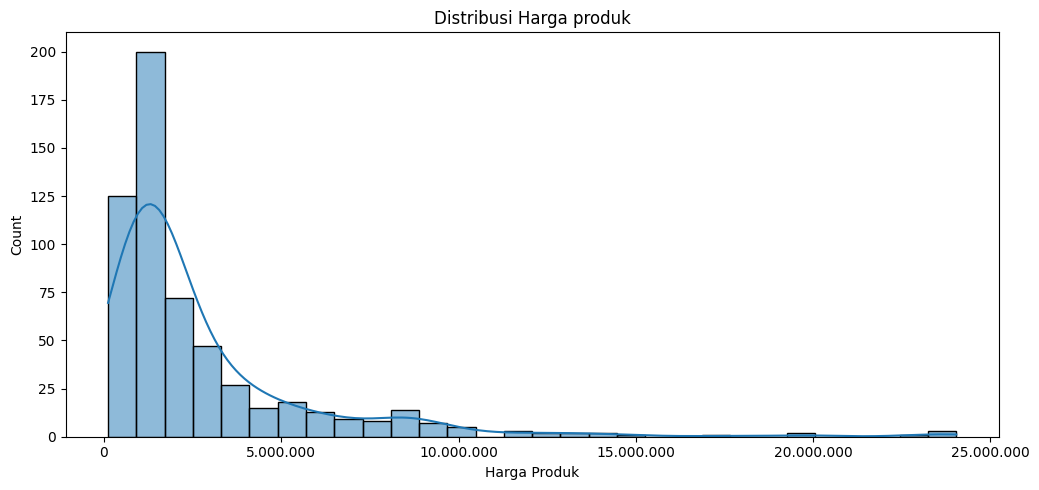

In [29]:
plt.figure(figsize = (20, 5))

# Plot 1: Distribusi dari Harga Produk
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(tokopedia['Harga_Produk'], bins = 30, kde = True)
plt.title('Distribusi Harga produk')
plt.xlabel('Harga Produk')
plt.ylabel('Count')

# Format x-axis labels (agar menampilkan angka harga lengkap dengan pemisah titik)
def currency_formatter(x, pos):
    return f'{int(x):,}'.replace(',', '.')

formatter = mticker.FuncFormatter(currency_formatter)
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

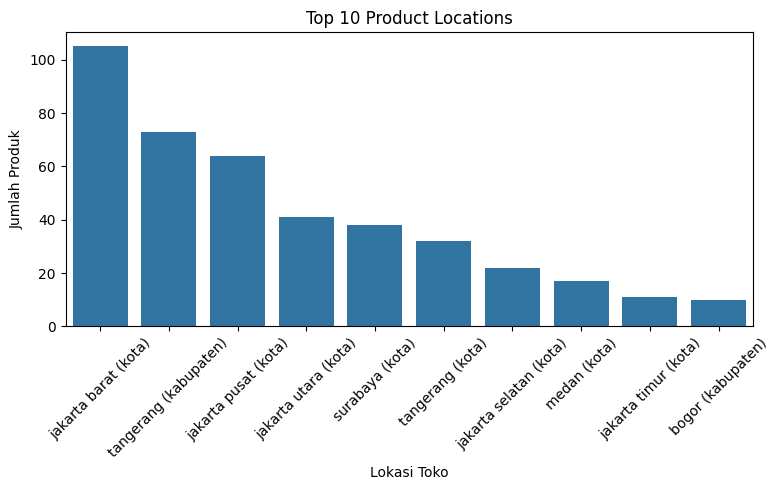

In [30]:
plt.figure(figsize = (15, 5))

# Plot 2: Top 10 dari Lokasi Toko
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
top_locations = tokopedia['Lokasi_Toko'].value_counts().head(10)
sns.barplot(x = top_locations.index, y = top_locations.values)
plt.title('Top 10 Product Locations')
plt.xlabel('Lokasi Toko')
plt.ylabel('Jumlah Produk')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

#### Penyimpanan Data

In [31]:
# Jumlah akhir data tokopedia
print(f"Jumlah Data Setelah Preprocessing: {tokopedia.shape[0]} baris, {tokopedia.shape[1]} kolom")

Jumlah Data Setelah Preprocessing: 577 baris, 5 kolom


In [32]:
# Nama kolom
print(f"Kolom: {tokopedia.columns.tolist()}")

Kolom: ['Produk', 'Harga_Produk', 'Produk_Terjual', 'Lokasi_Toko', 'E-Commerce']


In [33]:
# Pengecekan data
tokopedia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Produk          577 non-null    object 
 1   Harga_Produk    577 non-null    float64
 2   Produk_Terjual  577 non-null    float64
 3   Lokasi_Toko     577 non-null    object 
 4   E-Commerce      577 non-null    object 
dtypes: float64(2), object(3)
memory usage: 22.7+ KB


In [34]:
# Statistika deskriptif
tokopedia.describe().round(3)

,Harga_Produk,Produk_Terjual
count,5.770000e+02,577.000
mean,2.777681e+06,308.374
std,3.309427e+06,1079.941
min,1.150000e+05,0.000
25%,1.000000e+06,5.000
50%,1.560000e+06,30.000
75%,3.099000e+06,100.000
max,2.403900e+07,10000.000


In [35]:
# Data final
tokopedia.head()

,Produk,Harga_Produk,Produk_Terjual,Lokasi_Toko,E-Commerce
0,"Infnix NOTE 40 Pro 5G - HP Flagship Gaming, Ka...",1309846.0,70.0,tangerang (kabupaten),tokopedia
1,[ Promo Akhir Tahun ] Iphone 17 Pro Max 1 TERA...,2888000.0,4.0,jakarta barat (kota),tokopedia
2,INFINIX HOT 50 NFC 8/128 GB GARANSI INDONESIA,1019538.0,2.0,bekasi (kabupaten),tokopedia
3,[NEW PRODUCT] Handphone Gaming REDMAGIC 11 PRO...,19498900.0,80.0,tangerang (kota),tokopedia
4,A3S RAM 6GB/128GB Fullset Segel Garansi 12 Bul...,659000.0,100.0,jakarta barat (kota),tokopedia


In [36]:
# Simpan hasil
tokopedia.to_csv('data_tokopedia_clean.csv', index = False)
print("File _data_tokopedia_clean.csv berhasil disimpan!")

File _data_tokopedia_clean.csv berhasil disimpan!
